## 1D CNN Multi-Class Classification Model for Spectral Impact Echo Data

<span style="font-size: 18px;">This Python script implements a 1D Convolutional Neural Network (CNN) in TensorFlow and Keras to perform multi-class defect classification on spectral Impact Echo data. The workflow preprocesses spectral samples with Min-Max scaling, handles class imbalance using SMOTE, and splits the dataset into stratified training, validation, and test sets. The 1D CNN architecture incorporates batch normalization, max pooling, L2 regularization, and dropout to optimize performance. The script concludes with detailed evaluations, generating training history plots, confusion matrices, ROC-AUC curves, and spatial heatmaps to map predictions across material slabs.</span>

## 1. Packages Import 

In [1]:
import json
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score, roc_curve, auc
from imblearn.over_sampling import SMOTE

from keras.models import Sequential
from keras.layers import Convolution1D, MaxPooling1D, Flatten, Dense, Dropout, BatchNormalization
from keras.callbacks import EarlyStopping
from itertools import cycle
from keras.utils import plot_model

In [2]:
warnings.filterwarnings("ignore")

## 2. Data Loading, Label Mapping, and Spectral Normalization

In [3]:
df = pd.read_csv('Train_test.csv', header=None)
df = df.drop(columns=[0])
df = df.T.reset_index(drop=True).T

df_target = df[df.columns[-1]].astype(int)
df_data = df.drop(columns=[df.columns[-1]])

# Scale features per sample
scaler = MinMaxScaler(feature_range=(0, 1))
for i in range(len(df_data)):
    d = scaler.fit_transform(np.array(df_data.iloc[i]).reshape(-1, 1))
    df_data.iloc[i] = np.array(d).reshape(500,)

df_data = df_data.iloc[:, 0:500]

In [4]:
print("Shape:", df_data.shape)

Shape: (1512, 500)


In [5]:
df_data.head(5)

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,0.0,0.002655,0.003124,0.003026,0.002523,0.002085,0.003432,0.006604,0.008247,0.003439,...,0.007206,0.007609,0.007028,0.006906,0.007541,0.007776,0.007364,0.007380,0.008010,0.007855
1,0.0,0.011564,0.007075,0.005243,0.018340,0.018707,0.009083,0.021868,0.011431,0.015861,...,0.112744,0.116558,0.161063,0.149420,0.105813,0.108682,0.135565,0.122223,0.100845,0.105671
2,0.0,0.006469,0.007613,0.007635,0.011772,0.006265,0.015893,0.037537,0.005481,0.044497,...,0.208708,0.212373,0.207158,0.195900,0.188245,0.181459,0.172635,0.169361,0.177995,0.184344
3,0.0,0.091903,0.081291,0.071264,0.075030,0.075968,0.083521,0.075717,0.088005,0.075584,...,0.139993,0.152376,0.197688,0.203492,0.175489,0.183510,0.196991,0.149856,0.097477,0.127270
4,0.0,0.002445,0.008908,0.009328,0.003115,0.006163,0.003546,0.008422,0.006118,0.009238,...,0.116561,0.116528,0.117286,0.113380,0.104468,0.093196,0.080020,0.062901,0.043166,0.037847


In [6]:
# Detailed summary of data types and memory usage
df_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1512 entries, 0 to 1511
Columns: 500 entries, 0 to 499
dtypes: float64(500)
memory usage: 5.8 MB


## 3. Data Splitting, MOTE Upsampling, and Data Reshaping

In [7]:
# 1. Stratified train-test split (30% test)
X_train_raw, X_test_raw, Y_train_raw, Y_test_raw = train_test_split(
    df_data, df_target, test_size=0.30, random_state=100, stratify=df_target
)

# 2. Oversample ONLY training data
oversample = SMOTE(random_state=42)
X_train_res, Y_train_res = oversample.fit_resample(X_train_raw, Y_train_raw)

# 3. Create explicit Stratified Validation Set from training data
X_tr, X_val, Y_tr, Y_val = train_test_split(
    X_train_res, Y_train_res, test_size=0.20, random_state=42, stratify=Y_train_res
)

# 4. Reshape all sets to 3D: (samples, 500, 1)
X_tr = np.array(X_tr).reshape(X_tr.shape[0], X_tr.shape[1], 1).astype('float32')
X_val = np.array(X_val).reshape(X_val.shape[0], X_val.shape[1], 1).astype('float32')
X_test = np.array(X_test_raw).reshape(X_test_raw.shape[0], 500, 1).astype('float32')

# 5. One-hot encode targets
num_category = 5
Y_tr = tf.keras.utils.to_categorical(Y_tr, num_category)
Y_val = tf.keras.utils.to_categorical(Y_val, num_category)
Y_test = tf.keras.utils.to_categorical(Y_test_raw, num_category)

##  4. 1D CNN Architecture & Compilation

In [8]:
model = Sequential([
    Convolution1D(16, kernel_size=3, padding='same', activation='relu', input_shape=(500, 1)),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Convolution1D(32, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling1D(pool_size=2),

    Convolution1D(64, kernel_size=3, padding='same', activation='relu'),
    BatchNormalization(),

    Flatten(),
    Dense(128, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4)),
    Dropout(0.4),
    Dense(5, activation='softmax')  # Multi-class output
])

adam = tf.keras.optimizers.Adam(learning_rate=0.001)
model.compile(loss='categorical_crossentropy', optimizer=adam, metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

In [9]:
history = model.fit(
    X_tr, Y_tr,
    epochs=100,
    batch_size=64,
    verbose=1,
    validation_data=(X_val, Y_val),  # Explicit validation set
    callbacks=[early_stopping]
)

Epoch 1/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.7134 - loss: 1.0956 - val_accuracy: 0.1995 - val_loss: 1.6634
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9833 - loss: 0.0917 - val_accuracy: 0.1995 - val_loss: 1.8298
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9956 - loss: 0.0505 - val_accuracy: 0.1995 - val_loss: 2.4100
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9983 - loss: 0.0407 - val_accuracy: 0.1995 - val_loss: 3.0066
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9976 - loss: 0.0396 - val_accuracy: 0.2870 - val_loss: 2.1189
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9964 - loss: 0.0416 - val_accuracy: 0.3384 - val_loss: 1.8337
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.9995 - loss: 0.0334 - val_accuracy: 0.4539 - val_loss: 2.0795
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9992 - loss: 0.0321 - val_accuracy: 0.

## 5. Training and Validation Metrics Visualization

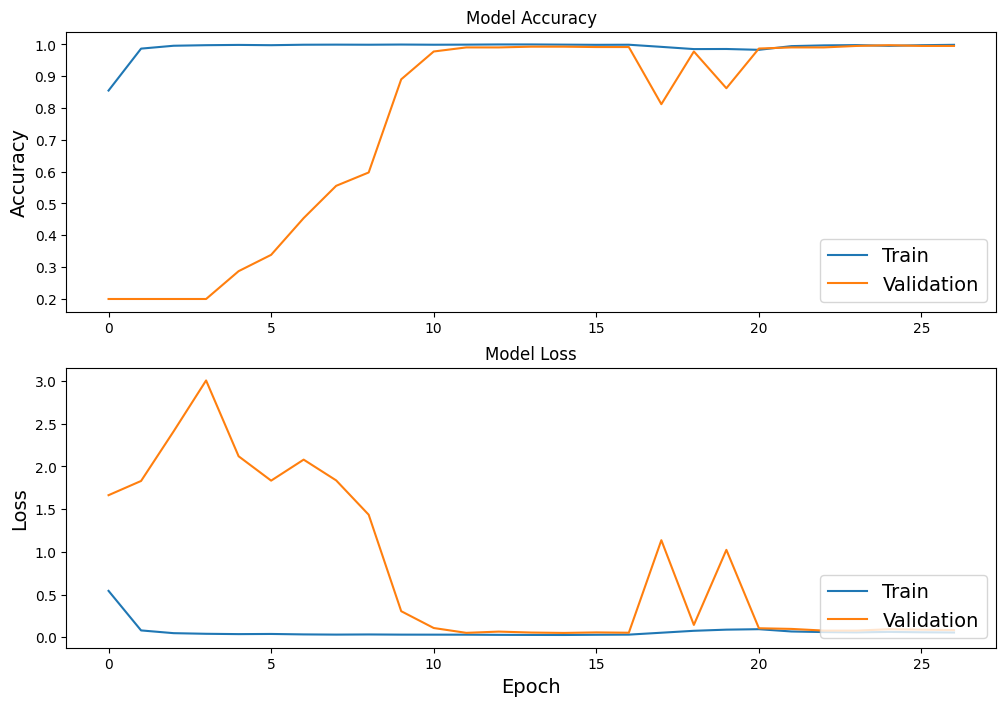

In [10]:
f, ax = plt.subplots(2 , figsize=(12,8))
ax[0].plot(history.history['accuracy'])
ax[0].plot(history.history['val_accuracy'])
ax[0].set_title('Model Accuracy')
ax[0].set_ylabel('Accuracy', fontsize=14)
ax[0].legend(['Train', 'Validation'], loc='lower right', fontsize = 14)


ax[1].plot(history.history['loss'])
ax[1].plot(history.history['val_loss'])
ax[1].set_title('Model Loss')
ax[1].set_ylabel('Loss', fontsize=14)
ax[1].set_xlabel('Epoch', fontsize=14)
ax[1].legend(['Train', 'Validation'], loc='lower right', fontsize = 14)

## 6. Performance Evaluation on Internal Test Set

=== Internal Test Set Performance (Train_test.csv) ===
Internal Test Loss: 0.7050
Internal Test Accuracy: 89.87%

Internal Test Confusion Matrix:
 [[359   1   2   0   5]
 [  6  14   0   0   2]
 [  3   0  15   2   2]
 [  9   0   4   7   1]
 [  7   0   2   0  13]]


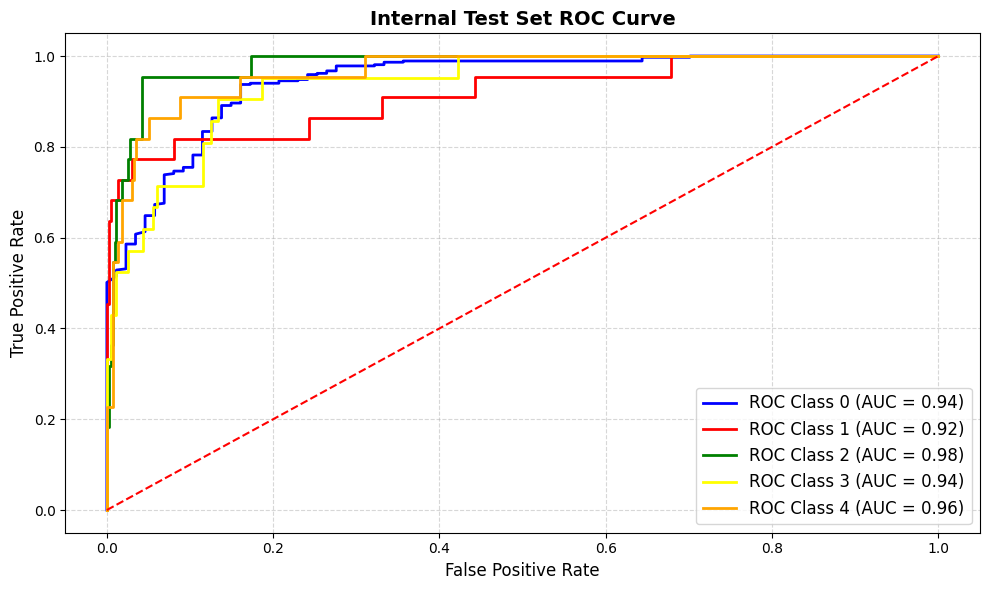

In [11]:
# --- EVALUATE ON INTERNAL TEST SET (from Train_test.csv) ---
print("=== Internal Test Set Performance (Train_test.csv) ===")

# 1. Loss & Accuracy
test_loss, test_acc = model.evaluate(X_test, Y_test, batch_size=64, verbose=0)
print(f"Internal Test Loss: {test_loss:.4f}")
print(f"Internal Test Accuracy: {test_acc * 100:.2f}%\n")

# 2. Confusion Matrix
test_predictions = model.predict(X_test, verbose=0)
test_pred_labels = np.argmax(test_predictions, axis=1)
test_true_labels = np.argmax(Y_test, axis=1)

internal_cm = confusion_matrix(test_true_labels, test_pred_labels)
print("Internal Test Confusion Matrix:\n", internal_cm)

# 3. Multi-Class ROC & AUC Curves on X_test
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_category):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], test_predictions[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(10, 6))
colors = cycle(['blue', 'red', 'green', 'yellow', 'orange'])
for i, color in zip(range(num_category), colors):
    plt.plot(
        fpr[i], tpr[i], color=color, lw=2,
        label=f'ROC Class {i} (AUC = {roc_auc[i]:.2f})'
    )

plt.plot([0, 1], [0, 1], 'r--')
plt.title('Internal Test Set ROC Curve', fontsize=14, fontweight='bold')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc='lower right', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 7. Independent Validation Dataset Loading & Preprocessing

In [12]:
from sklearn import preprocessing
df = pd.read_csv('Validation.csv', header = None)
df_data = df.drop(columns=[df.columns[-1],df.columns[0]])
df_target = df[501]
df_loc = df[0]

df_upsampled = []
for i in range(0, df.shape[0]):
    scaler = preprocessing.MinMaxScaler(feature_range=(0, 1))
    amplitude = scaler.fit_transform(np.array(df_data.iloc[i]).reshape(-1,1))
    amplitude = np.array(amplitude).reshape(500,)
    df_upsampled.append(amplitude)
    
df_upsampled = pd.DataFrame(df_upsampled)

In [13]:
df_upsampled_arr = np.array(df_upsampled).reshape(df_upsampled.shape[0], df_upsampled.shape[1], 1).astype('float32')

predictions = model.predict(df_upsampled_arr, verbose=0)
converted_predictions = []
for i in predictions:
    for k in range(0, len(i)):
        if i[k] == max(i):
            converted_predictions.append(k)
            break

matrix = confusion_matrix(df_target, converted_predictions)
print(matrix)

accuracy = accuracy_score(df_target, converted_predictions)
print(accuracy)

[[396   3   7   1   1]
 [  5  16   3   0   0]
 [ 10   2   7   3   2]
 [ 11   0   0  11   2]
 [  9   0   0   1  14]]
0.8809523809523809


## 8. Multi-Class ROC and AUC Analysis on Independent Validation Set

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


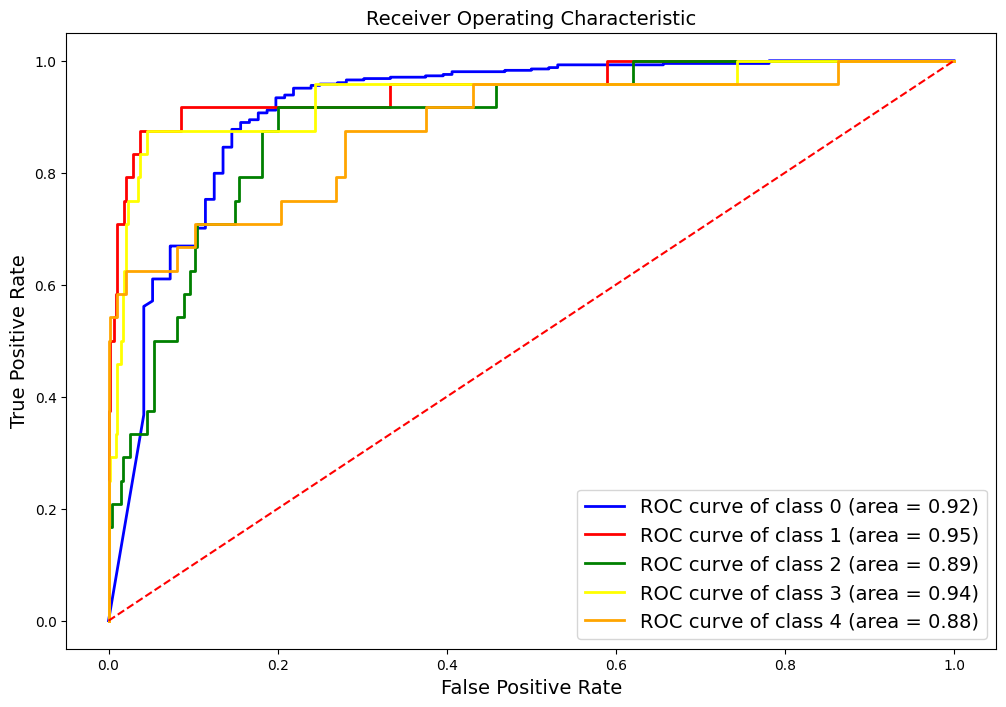

In [14]:
from sklearn.metrics import roc_curve, auc
from itertools import cycle
Y_test = tf.keras.utils.to_categorical(df_target, num_category)

probs = model.predict(df_upsampled_arr)
fpr = dict()
tpr = dict()
roc_auc = dict()
lw=2
for i in range(5):
    fpr[i], tpr[i], _ = roc_curve(Y_test[:, i], probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
f, ax = plt.subplots(figsize=(12,8))
colors = cycle(['blue', 'red', 'green', 'yellow', 'orange'])
for i, color in zip(range(5), colors):
    ax.plot(fpr[i], tpr[i], color=color, lw=2,
             label='ROC curve of class {0} (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))
ax.plot([0, 1], [0, 1],'r--')
ax.set_title('Receiver Operating Characteristic', fontsize = 14)
ax.set_ylabel('True Positive Rate', fontsize = 14)
ax.set_xlabel('False Positive Rate', fontsize = 14)
ax.legend(loc='lower right', fontsize = 14)

## 9. Spatial Heatmap Visualizations of Predictions (Slab 3 & Slab 8)

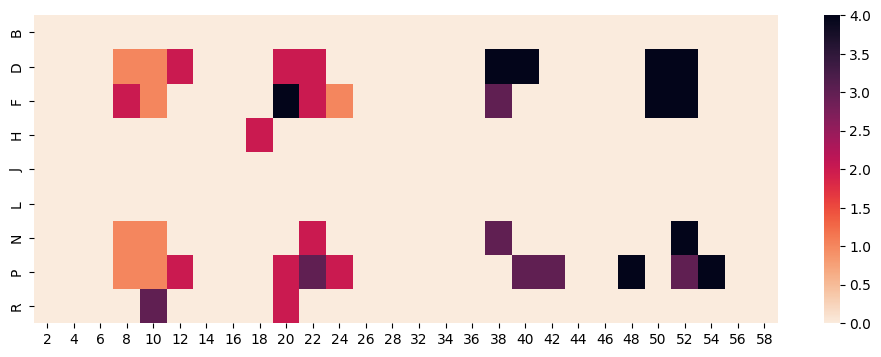

In [15]:
df = pd.DataFrame(df_loc)
df = df[0].str.split('/', expand = True)
df[2] = converted_predictions
df = df[df[0].str.contains("Slab3")]
slab_df = df[1].str.split('-', expand = True)
slab_df[2] = df[2]
slab_df = slab_df.reset_index(drop = True)

rows = ['2','4','6','8','10','12','14','16','18','20','22','24','26','28','32','34','36','38','40','42','44','46','48','50','52','54','56','58']
cols = ["B", "D", "F", "H", "J", "L", "N", "P", "R"]

new_df = pd.DataFrame(columns = rows, index = cols )
for i in range(0,len(df)):
    new_df.at[slab_df[0][i], slab_df[1][i]] = float(slab_df[2][i])
new_df = new_df.fillna(5.0)
cmap = sns.cm.rocket_r
f, ax = plt.subplots(figsize=(12,4))
plt.axis('on')
ax = sns.heatmap(new_df,cbar = True,annot=False, cmap=cmap)

In [16]:
"""f.savefig("Slab3_predicted_FNN.svg")"""

'f.savefig("Slab3_predicted_FNN.svg")'

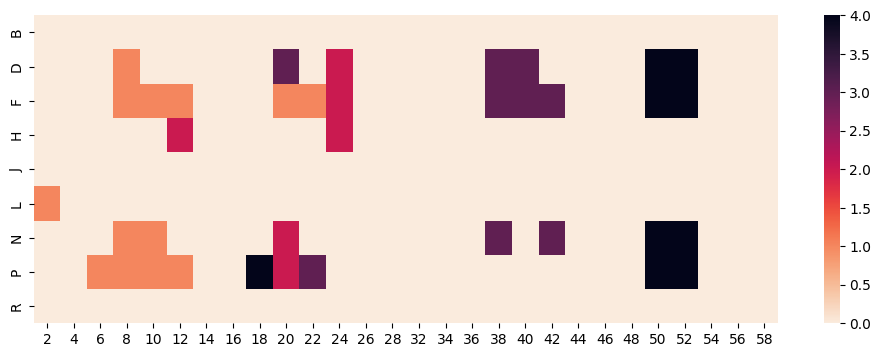

In [17]:
df = pd.DataFrame(df_loc)
df = df[0].str.split('/', expand = True)
df[2] = converted_predictions
df = df[df[0].str.contains("Slab8")]
slab_df = df[1].str.split('-', expand = True)
slab_df[2] = df[2]
slab_df = slab_df.reset_index(drop = True)

rows = ['2','4','6','8','10','12','14','16','18','20','22','24','26','28','32','34','36','38','40','42','44','46','48','50','52','54','56','58']
cols = ["B", "D", "F", "H", "J", "L", "N", "P", "R"]

new_df = pd.DataFrame(columns = rows, index = cols )
for i in range(0,len(df)):
    new_df.at[slab_df[0][i], slab_df[1][i]] = float(slab_df[2][i])
new_df = new_df.fillna(5.0)
cmap = sns.cm.rocket_r
f, ax = plt.subplots(figsize=(12,4))
plt.axis('on')
ax = sns.heatmap(new_df,cbar = True,annot=False, cmap=cmap)

In [18]:
"""f.savefig("Slab8_predicted_FNN.svg")"""

'f.savefig("Slab8_predicted_FNN.svg")'

In [19]:
model_json = model.to_json()
with open("5class_model.json", "w") as json_file:
    json_file.write(model_json)

# serialize weights to HDF5
model.save_weights("5class_model.weights.h5")
print("Saved model to disk")

Saved model to disk


In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                      │ (None, 500, 16)             │              64 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 500, 16)             │              64 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d (MaxPooling1D)         │ (None, 250, 16)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_1 (Conv1D)                    │ (None, 250, 32)             │           1,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 250, 32)             │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_1 (MaxPooling1D)       │ (None, 125, 32)             │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_2 (Conv1D)                    │ (None, 125, 64)             │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 125, 64)             │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8000)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       1,024,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,098,737 (11.82 MB)

 Trainable params: 1,032,837 (3.94 MB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 2,065,676 (7.88 MB)

In [21]:
# import visualkeras
# visualkeras.graph_view(model)

In [22]:
# from IPython.display import Markdown, display

# def draw_flowchart(model):
#     mermaid_code = ["```mermaid", "graph TD"]
#     for i, layer in enumerate(model.layers):
#         # Format node text (Name + Layer Type)
#         node_id = f"L{i}"
#         node_label = f"{layer.name}<br/>({layer.__class__.__name__})"
#         mermaid_code.append(f"    {node_id}[\"{node_label}\"]")
        
#         # Draw arrow from previous layer to current layer
#         if i > 0:
#             prev_id = f"L{i-1}"
#             mermaid_code.append(f"    {prev_id} --> {node_id}")
            
#     mermaid_code.append("```")
#     display(Markdown("\n".join(mermaid_code)))
# draw_flowchart(model)